In [59]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import NMF, PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

import umap
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
customer_data_raw = pd.read_csv("../data/raw/Mall_Customers.csv")
customer_data_raw.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
customer_data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Software para el ejercicio

In [75]:
class UnsupervisedProcessor:
    def __init__(self,
                 dataframe: pd.DataFrame,
                 scaler,
                 cluster_algorithm,
                 dim_reduction_algorithm,
                 ) -> None:
        self.original_data = dataframe
        self.cluster_pipeline = Pipeline(
            steps= [
                ("scaler", scaler),
                ("cluster_algorithm", cluster_algorithm)
            ]
        )
        self.dim_reduction_pipeline = Pipeline(
            steps= [
                ("scaler", StandardScaler()),
                ("dim_reduction", dim_reduction_algorithm)
            ]
        )

    
    def __process_clustering(self, columns: list) -> pd.DataFrame:
        
        tmp_data_to_process = self.original_data[columns]
        #print(tmp_data_to_process.columns)
        self.cluster_pipeline.fit(tmp_data_to_process)

        clustering_df = pd.concat(
            [
                self.original_data["CustomerID"],
                self.original_data[self.original_data.columns[-3:]],
                pd.DataFrame(
                    self.cluster_pipeline.steps[1][1].labels_,
                    columns= ["cluster"]
                )
            ],
            axis= 1
        )

        return clustering_df

    def __process_dim_reduction(self, columns: list) -> pd.DataFrame:

        #N_DIMENTIONS = 2

        tmp_data_to_process = self.original_data[columns]
        return pd.concat(
            [self.original_data["CustomerID"],
             pd.DataFrame(self.dim_reduction_pipeline.fit_transform(tmp_data_to_process),
                          columns = ["dim1", "dim2"])
            ]
        , axis= 1)
    
    def run(self, columns: list) -> pd.DataFrame:
        
        _cluster_results = self.__process_clustering(columns= columns)
        #print(type(_cluster_results))
        #print(_cluster_results.columns)
        _dim_reduction_results = self.__process_dim_reduction(columns= columns)
        #print(type(_dim_reduction_results))
        #print(_dim_reduction_results.columns)
        return _cluster_results.merge(_dim_reduction_results, on= "CustomerID", how= "left")


def calculate_custering_metrics(data: pd.DataFrame):
    
    print(
        f"""
        Métrica Silloutte: {silhouette_score(X= data[customer_data_raw.columns[-3:]], labels= data["cluster"])}
        Métrica calinski_harabasz_score: {calinski_harabasz_score(X= data[customer_data_raw.columns[-3:]], labels= data["cluster"])}
        Métrica davies_bouldin_score: {davies_bouldin_score(X= data[customer_data_raw.columns[-3:]], labels= data["cluster"])}
"""
        )
    plot_results(dataframe= data)

def plot_results(dataframe: pd.DataFrame):
    sns.scatterplot(
        x= "dim1",
        y= "dim2",
        data= dataframe,
        hue= "cluster",
        palette = "tab10"
    )

In [17]:
processor = UnsupervisedProcessor(
    dataframe= customer_data_raw,
    scaler= StandardScaler(),
    cluster_algorithm= KMeans(n_clusters= 2),
    dim_reduction_algorithm= PCA(n_components= 2)
)

In [18]:
customer_data_raw.columns[-3:]

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [22]:
df_final = processor.run(columns= customer_data_raw.columns[-3:])

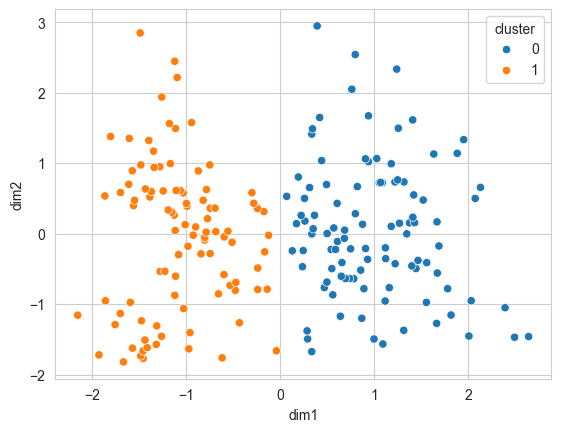

In [27]:
plot_results(dataframe= df_final)

##### Datos dispersos de forma interesante, por lo que las técnicas de reducción de dimensionalidad que vamos a aplicar nos van a servir

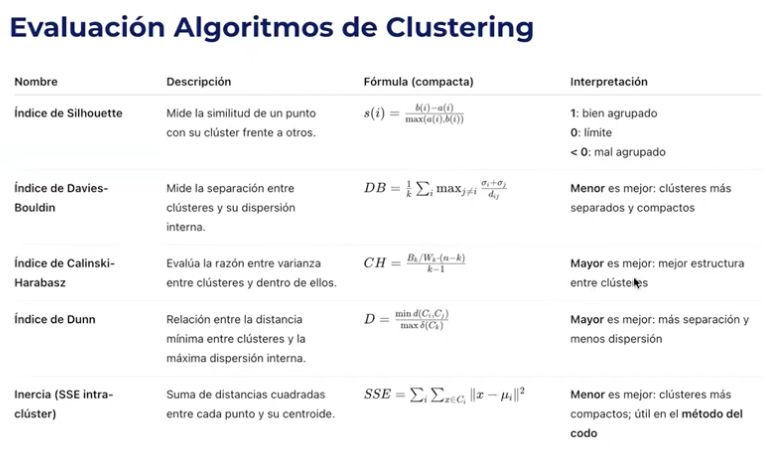

In [66]:
from IPython.display import display, Image
display(Image("metricss.jpeg"))


        Métrica Silloutte: 0.276257743689132
        Métrica calinski_harabasz_score: 80.9941085399689
        Métrica davies_bouldin_score: 1.4425153781248279



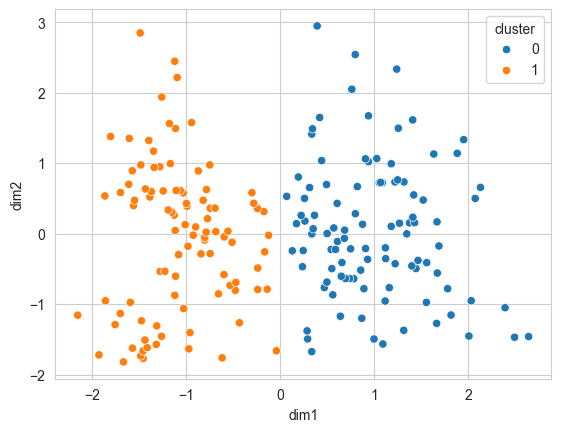

In [68]:
calculate_custering_metrics(data= df_final)

In [51]:
processor_2 = UnsupervisedProcessor(
    dataframe= customer_data_raw,
    scaler= StandardScaler(),
    cluster_algorithm= DBSCAN(),
    dim_reduction_algorithm= TSNE(n_components= 2)
)

In [52]:
df_final_2 = processor_2.run(columns= customer_data_raw.columns[-3:])

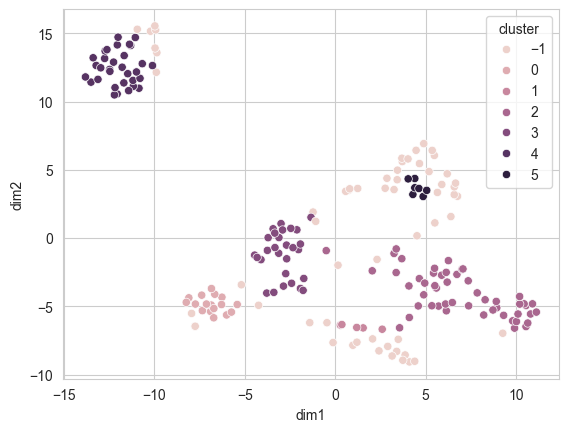

In [53]:
plot_results(dataframe= df_final_2)


        Métrica Silloutte: 0.1815617726633181
        Métrica calinski_harabasz_score: 31.06346473008879
        Métrica davies_bouldin_score: 1.7437710441549679



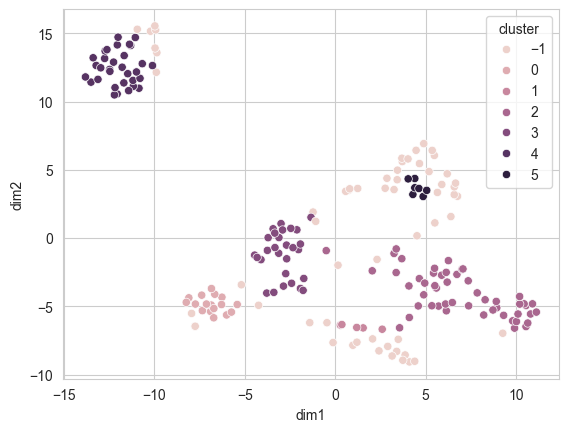

In [69]:
calculate_custering_metrics(data= df_final_2)

In [54]:
processor_3 = UnsupervisedProcessor(
    dataframe= customer_data_raw,
    scaler= StandardScaler(),
    cluster_algorithm= OPTICS(),
    dim_reduction_algorithm= TSNE(n_components= 2)
)

In [55]:
df_final_3 = processor_3.run(columns= customer_data_raw.columns[-3:])

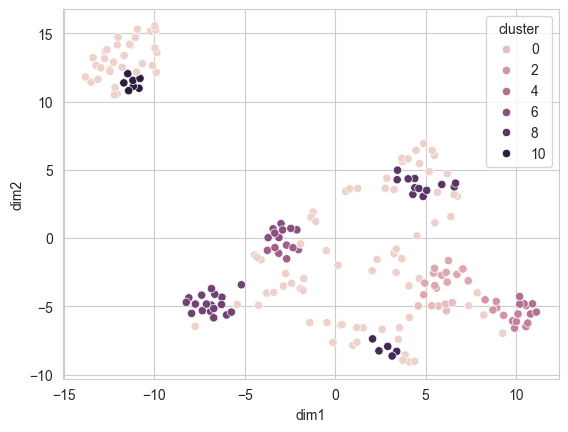

In [56]:
plot_results(dataframe= df_final_3)


        Métrica Silloutte: -0.08657995583439312
        Métrica calinski_harabasz_score: 9.188817273522508
        Métrica davies_bouldin_score: 1.8736091509238213



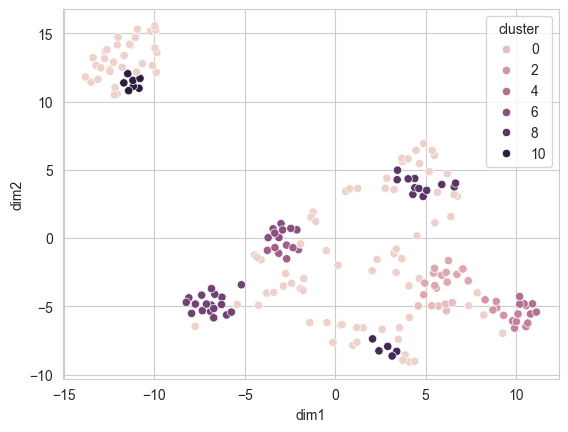

In [70]:
calculate_custering_metrics(data= df_final_3)

In [76]:

processor_4 = UnsupervisedProcessor(
    dataframe= customer_data_raw,
    scaler= StandardScaler(),
    cluster_algorithm= OPTICS(),
    dim_reduction_algorithm= umap.UMAP(n_components= 2)
)

In [77]:
df_final_4 = processor_4.run(columns= customer_data_raw.columns[-3:])



        Métrica Silloutte: -0.08657995583439312
        Métrica calinski_harabasz_score: 9.188817273522508
        Métrica davies_bouldin_score: 1.8736091509238213



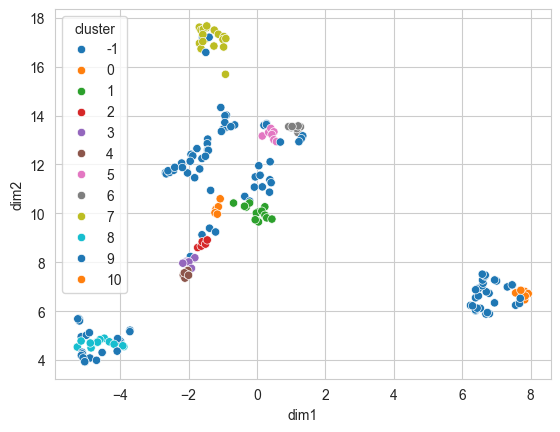

In [78]:
calculate_custering_metrics(data= df_final_4)